In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [2]:
import matplotlib.pyplot as plt
from neuroaging.visualization import (
    configure_plotting,
    savefig_nice,
    COL_RAW,
    COL_WEIGHTED,
    COL_REF,
    COL_CENSUS,
    CMAP_RAW,
    CMAP_WEIGHTED,
)

configure_plotting()


2026-01-14 10:23:00.248 | INFO     | neuroaging.config:<module>:11 - PROJ_ROOT path is: /home/galkepler/Projects/neuroaging


In [3]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
# DATA_DIR = Path("/media/groot/Minerva/phd/neuroaging/data")
DATA_DIR = Path("/media/storage/phd/neuroaging/data")

# Output directory for figures
# OUTPUT_DIR = Path("/media/groot/Minerva/phd/neuroaging/figures/revision/fig3")
OUTPUT_DIR = Path("/media/storage/phd/neuroaging/figures/revision/fig3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [4]:
metrics = ["gm_vol", "adc"]
distribution_metric = "qfmean"

bad_subjects = ["IN120120"]

# Load the data
all_data = {}
for metric in metrics:
    all_data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
        drop=True
    )
    # drop problematic subjects
    all_data[metric] = all_data[metric][~all_data[metric]["subject_code"].isin(bad_subjects)]
    all_data[metric]["sex"] = all_data[metric]["sex"].map({"M": 0, "F": 1})


# data["age_squared"] = data["age_at_scan"] ** 2

/tmp/ipykernel_14186/485535177.py:9: DtypeWarning: Columns (1,7,61,67,71,72,73,74,75,77,78,79,80,85,86,87,88,89,90,92,106,108,109,114,115,116,117,118,125,126,127) have mixed types. Specify dtype option on import or set low_memory=False.
  all_data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
/tmp/ipykernel_14186/485535177.py:9: DtypeWarning: Columns (16,22,23,26,32,36,37,38,39,40,42,43,44,45,50,51,52,53,54,55,57,71,73,74,79,80,81,82,89,90,91,101) have mixed types. Specify dtype option on import or set low_memory=False.
  all_data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(


In [5]:
metric_cols = {metric: "volume" if "vol" in metric else distribution_metric for metric in metrics}

for m, df in all_data.items():
    df = df.rename(columns={metric_cols[m]: "value"})
    all_data[m] = df

In [6]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [7]:
from neuroaging.stats import compute_joint_poststrat_weights

In [8]:
# assign weights
for _, data in all_data.items():
    data["weight"], _ = compute_joint_poststrat_weights(
        data,
        israel_population,
        age_col="age_at_scan",
        sex_col="sex",
        return_bin_table=True,
        cap=10  # Optional: prevents any single female/male from having too much influence
    )

In [9]:
from neuroaging.modeling.regional import fit_regional_models, apply_fdr_correction

from neuroaging.modeling.regional import fit_regional_models, apply_fdr_correction

# Centering option
CENTER_VARIABLES = True

results = {}

for metric, data in all_data.items():
    metric_col = "volume" if metric == "gm_vol" else distribution_metric
    # Set up dataframes to store results
    quad_w, lin_w = parcels.copy(), parcels.copy()

    mean_age = data["age_at_scan"].mean()

    covariates = ["age_c", "C(sex)"]
    if metric == "gm_vol":
        covariates += ["tiv"]
    models = fit_regional_models(
        data,
        parcels,
        region_col=region_col,
        metric_col=metric_col,
        covariates=covariates,
        center_variables=True
    )

    apply_fdr_correction(models)
    results[metric] = models


In [10]:
from tqdm import tqdm

from neuroaging.modeling.ast import stabilization_age




for metric, data in all_data.items():

    for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
        lin_model = results[metric].linear.loc[i, "model"]
        quad_model = results[metric].quadratic.loc[i, "model"]

        f, p, _ = quad_model.compare_f_test(lin_model)
        delta_aic = quad_model.aic - lin_model.aic
        for results_df, model, is_quadratic in zip(
            [results[metric].linear, results[metric].quadratic],
            [lin_model, quad_model],
            [False, True],
        ):
            # Store the results
            results_df.loc[i, "model"] = model
            results_df.loc[i, "aic"] = model.aic
            results_df.loc[i, "pvalue"] = model.f_pvalue
            results_df.loc[i, "r2"] = model.rsquared
            results_df.loc[i, "r2_adj"] = model.rsquared_adj
            results_df.loc[i, "intercept"] = model.params["Intercept"]
            results_df.loc[i, "t_intercept"] = model.tvalues["Intercept"]
            results_df.loc[i, "pvalue_intercept"] = model.pvalues["Intercept"]
            results_df.loc[i, "beta1"] = model.params["age_c"]
            results_df.loc[i, "se_beta1"] = model.bse["age_c"]
            results_df.loc[i, "t_beta1"] = model.tvalues["age_c"]
            results_df.loc[i, "pvalue_beta1"] = model.pvalues["age_c"]

            if is_quadratic:
                results_df.loc[i, "beta2"] = model.params["I(age_c ** 2)"]
                results_df.loc[i, "se_beta2"] = model.bse["I(age_c ** 2)"]
                results_df.loc[i, "t_beta2"] = model.tvalues["I(age_c ** 2)"]
                results_df.loc[i, "pvalue_beta2"] = model.pvalues["I(age_c ** 2)"]
                beta1, beta2 = (
                    model.params["age_c"],
                    model.params["I(age_c ** 2)"],
                )
                if delta_aic < -15:
                    # We only attempt to find a vertex if the quadratic is significantly better
                    age_star, clipped, u = stabilization_age(
                        metric,
                        {"age": quad_model.params["age_c"], "age_sq": quad_model.params["I(age_c ** 2)"]},
                        mean_age
                    )
                else:
                    # For linear or non-sig models, we default to the start of the lifespan
                    age_star, clipped, u = 18, True, (quad_model.params["I(age_c ** 2)"] > 0)
                results_df.loc[i, "age_star"] = age_star
                results_df.loc[i, "clipped"] = clipped
            else:
                results_df.loc[i, "beta2"] = 0
                results_df.loc[i, "se_beta2"] = 0
                results_df.loc[i, "t_beta2"] = 0
                results_df.loc[i, "pvalue_beta2"] = 1
                results_df.loc[i, "age_star"] = 18
                results_df.loc[i, "clipped"] = True


Fitting models: 100%|██████████| 454/454 [00:01<00:00, 238.09it/s]


In [11]:
example_rois = [405, 179, 50]
parcels.loc[example_rois]

,index,name,base_name,Label Name,network,component,hemisphere
405,406,HIP-body-rh,HIP-body,Hippocampus body,subcortex,Hippocampus body,R
179,180,7Networks_LH_Default_PFC_15,7networks_lh_default_pfc,7Networks_LH_Default_PFC,default,prefrontal cortex,L
50,51,7Networks_LH_SomMot_20,7networks_lh_sommot,7Networks_LH_SomMot,somatomotor,somatomotor,L


In [12]:
metrics_vis = {"gm_vol": "GM Vol.", "adc": "MD"}

gm_vol --- Linear --- 0.4029250748401595
gm_vol --- Quadratic --- 0.44464180008350385


/tmp/ipykernel_14186/3099713123.py:157: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(lines, labels, frameon=False, fontsize=35, loc="upper right")
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not f

adc --- Linear --- 0.17739396525618223
adc --- Quadratic --- 0.3478572036909443
gm_vol --- Linear --- 0.5169415437344163
gm_vol --- Quadratic --- 0.5228057298432045
adc --- Linear --- 0.2090110339429584
adc --- Quadratic --- 0.27854703223299426


/tmp/ipykernel_14186/3099713123.py:157: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(lines, labels, frameon=False, fontsize=35, loc="upper right")


gm_vol --- Linear --- 0.27892328651008447
gm_vol --- Quadratic --- 0.27944292256265224
adc --- Linear --- 0.2724377110794699
adc --- Quadratic --- 0.2732955204201645


/tmp/ipykernel_14186/3099713123.py:157: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(lines, labels, frameon=False, fontsize=35, loc="upper right")


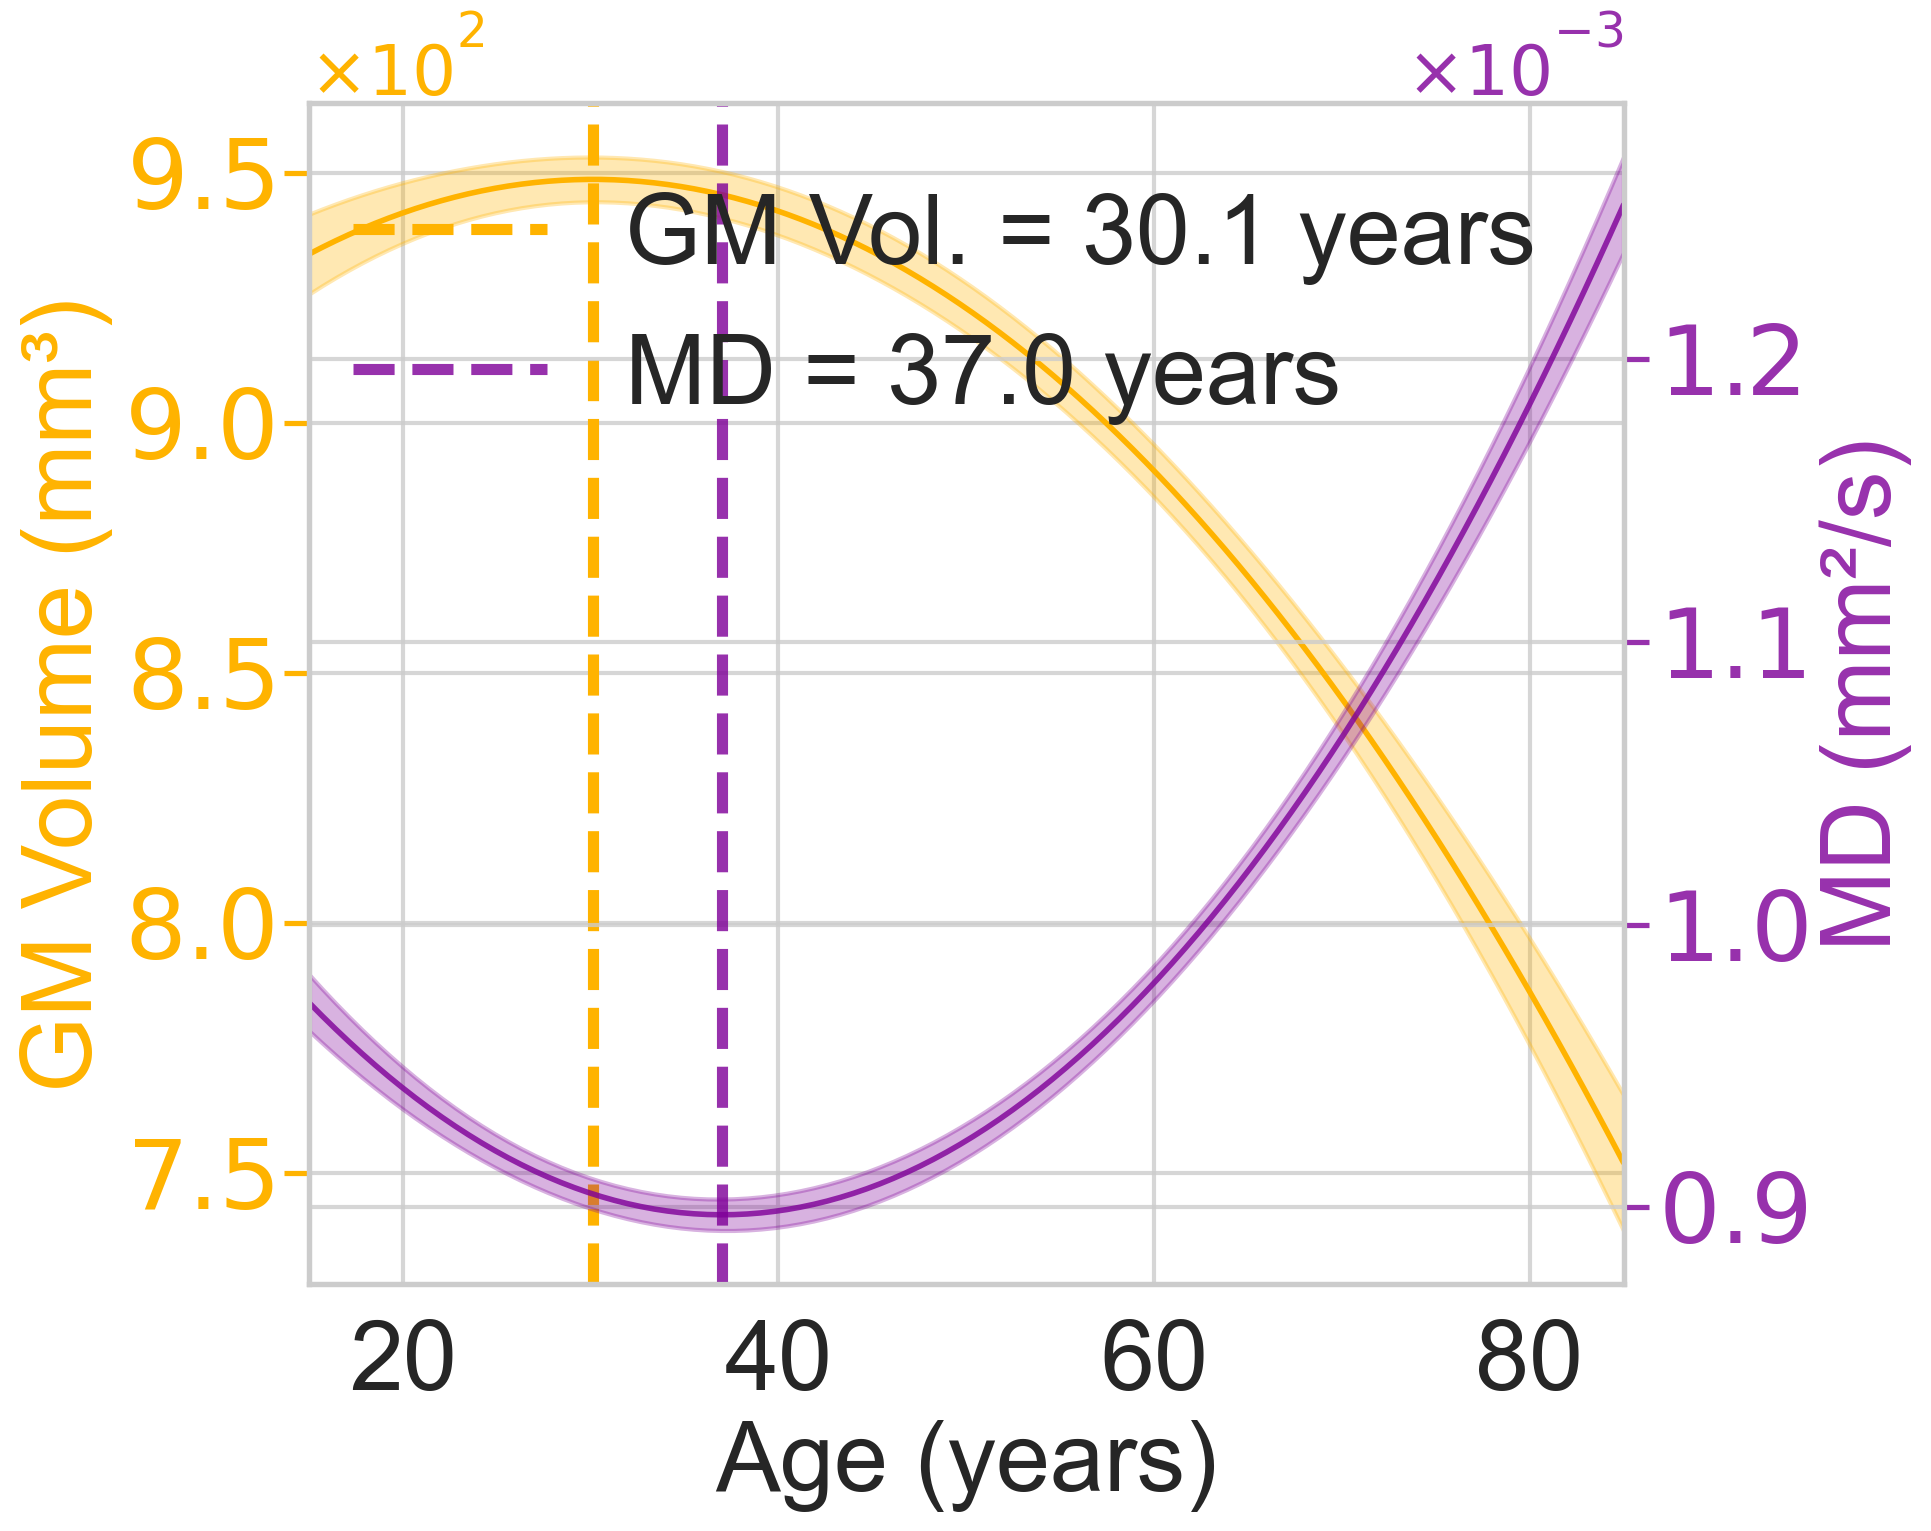

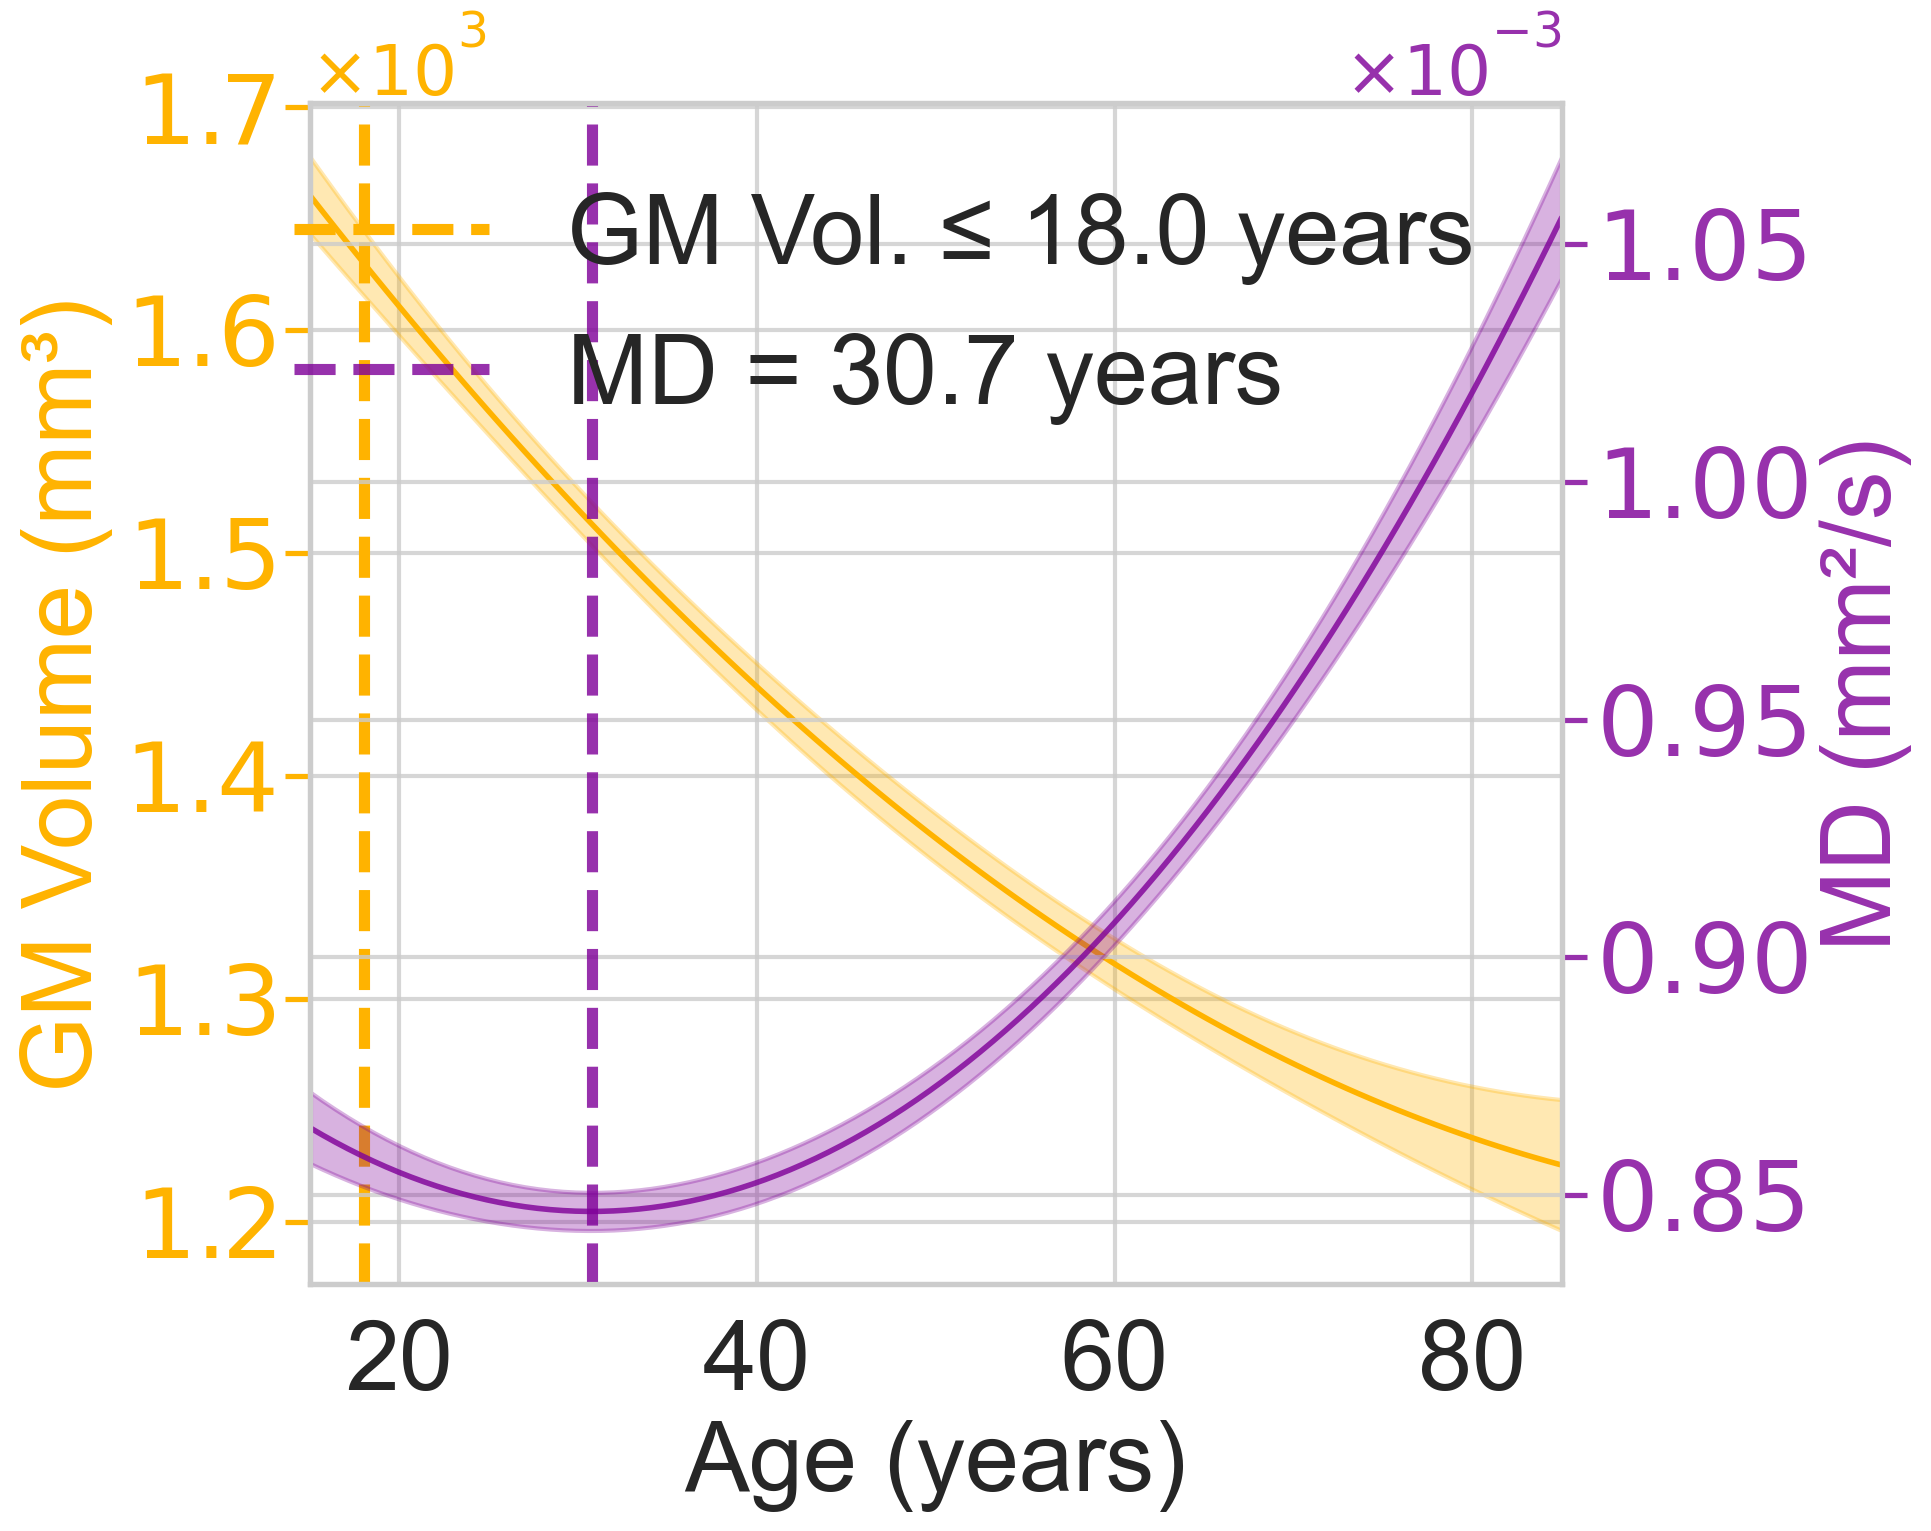

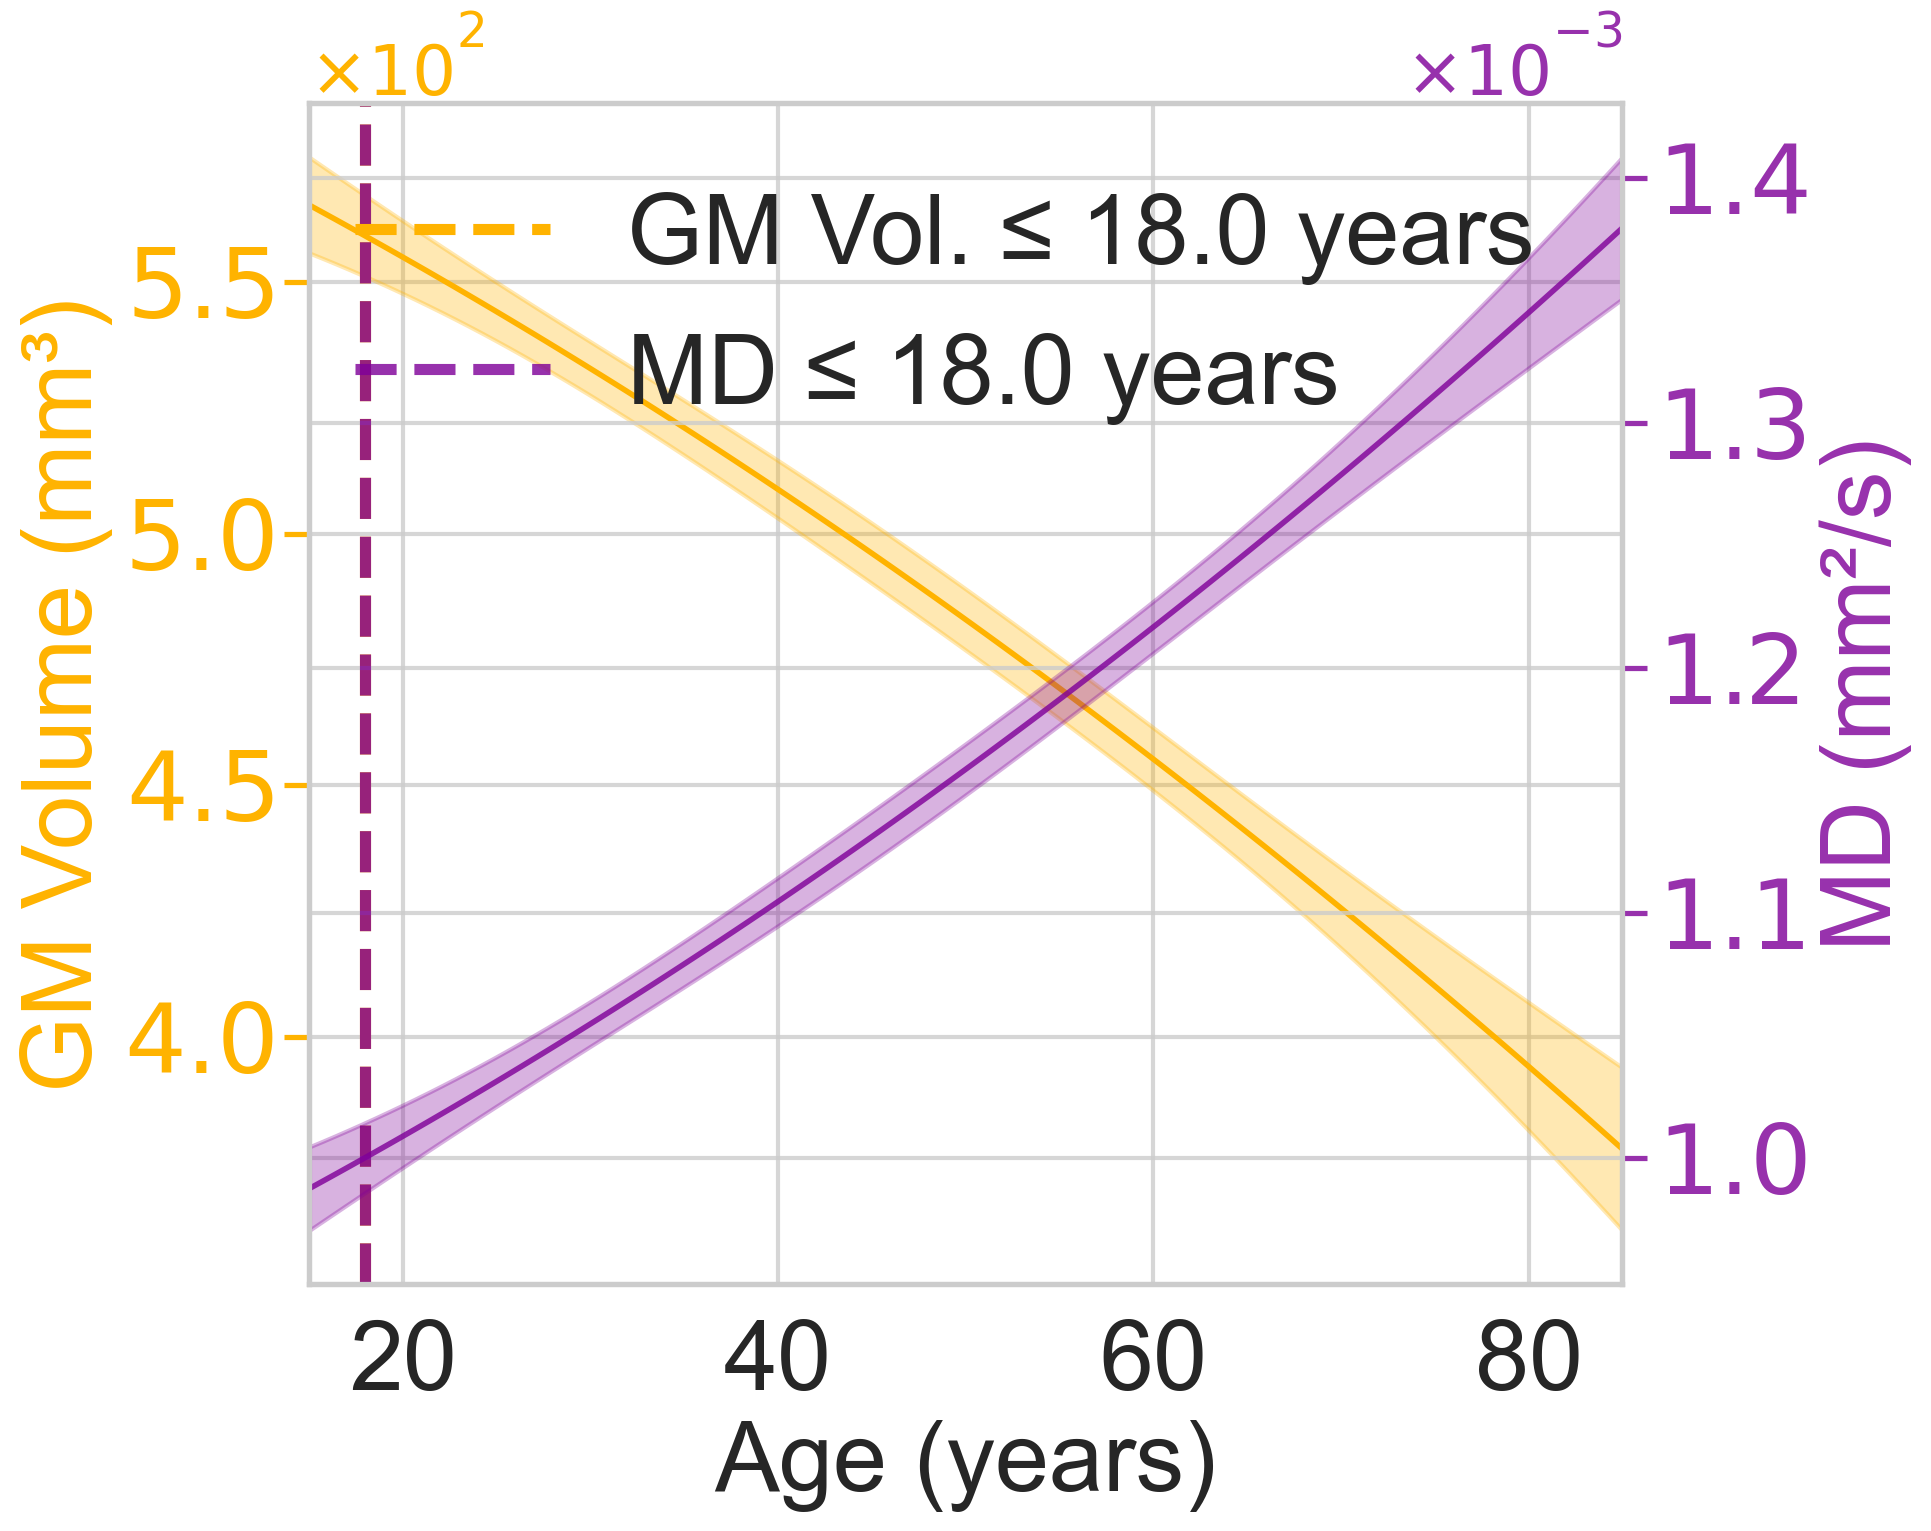

In [13]:
age_min, age_max = 15, 85
age_col = "age_c"

i = 413


# d = d[(d[metric_col] > d[metric_col].quantile(0.001))]

# ────────────────── Panel B: Predicted trajectory ± 95 % CI ──────────────

mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25})

for i in example_rois:
    fig, ax1 = plt.subplots(figsize=(10, 8))
    ax2 = ax1.twinx()  # create a second y-axis for the second metric
    # move y label to the right for the second axis
    lines = []
    labels = []
    for metric, ax, color, sci_limits in zip(
        metrics, [ax1, ax2], [COL_RAW, COL_WEIGHTED], [(0, 0), (0, 100)]
    ):
        # stab_df = models[metric]["stab_df"]
        metric_col = metric_cols[metric]
        lm = results[metric].linear.loc[i, "model"]
        qm = results[metric].quadratic.loc[i, "model"]
        w_compare = results[metric].comparison

        d = all_data[metric].copy()
        d = d[d[region_col] == parcels.loc[i, region_col]].copy()
        # remove outliers
        d = d[
            (d["value"] > d["value"].quantile(0.001)) & (d["value"] < d["value"].quantile(0.999))
        ]

        # 3. Prediction frame

        # ── 3. Prediction grid ──────────────────────────────────────────────
        is_centered = age_col == "age_c"
        if is_centered:
            mean_age = all_data[metric]["age_at_scan"].mean()
            age_grid = np.linspace(age_min - mean_age, age_max - mean_age, 100)
            age_grid_vis = age_grid + mean_age
        else:
            age_grid = np.linspace(age_min, age_max, 100)
            age_grid_vis = age_grid
        grid_df = pd.DataFrame({age_col: age_grid, "age_squared": age_grid**2})

        # add any covariates present in models (use median/mode)
        covs = [
            v
            for v in qm.model.exog_names
            if v not in ["Intercept", age_col, "age_c", "I(age_c ** 2)"]
        ]
        for c in covs:
            # if pd.api.types.is_numeric_dtype(d[c]):
            if "sex" in c:
                grid_df["sex"] = d["sex"].mode()[0]
            else:
                grid_df[c] = d[c].median()

        # 4. Get predictions & CI
        for tag, model in [("Linear", lm), ("Quadratic", qm)]:
            pr = model.get_prediction(grid_df)
            ci = pr.conf_int(alpha=0.05)
            grid_df[f"{tag}_fit"] = pr.predicted_mean
            grid_df[f"{tag}_lo"] = ci[:, 0]
            grid_df[f"{tag}_hi"] = ci[:, 1]
            print(metric, "---", tag, "---", model.rsquared_adj)
            # if is_centered:
            #     grid_df[f"{tag}_fit"] = grid_df[f"{tag}_fit"] + mean_age
            #     grid_df[f"{tag}_lo"] = grid_df[f"{tag}_lo"] + mean_age
            #     grid_df[f"{tag}_hi"] = grid_df[f"{tag}_hi"] + mean_age

        # 5. Plot
        ax.clear()  # reuse the same axes handle

        # Background scatter (down-sample for speed / clarity)
        sizes = np.clip(d["weight"] * 10, 0, 100)
        # sns.scatterplot(
        #     data=d,
        #     x=age_col,
        #     y="value",
        #     alpha=0.7,
        #     s=sizes,
        #     edgecolor="none",
        #     ax=ax,
        #     legend=False,
        #     color=COL_REF,
        # )
        is_quadratic = w_compare.loc[i, "delta_AIC"] < -15
        if is_quadratic:
            model = qm
        else:
            model = lm
        # # Fit lines & ribbons
        # for tag, color, model in zip(["Linear", "Quadratic"], [COL_RAW, COL_WEIGHTED], [lm, qm]):
        # label = f"{tag} - $R^2$ = {model.rsquared:.2f}, AIC = {model.aic:.1f}"
        label = f"{metric} - $R^2$ = {model.rsquared_adj:.2f}"
        lines.append(ax.plot(age_grid_vis, grid_df["Quadratic_fit"], label=label, lw=2, color=color))
        labels += [label]
        ax.fill_between(
            age_grid_vis,
            grid_df["Quadratic_lo"],
            grid_df["Quadratic_hi"],
            color=color,
            alpha=0.3,
        )

        # add age star
        stab_age = results[metric].quadratic.loc[i, "age_star"]
        stab_age = stab_age if not np.isnan(stab_age) else 18
        metric_vis = metrics_vis.get(metric, metric)
        if stab_age > 18:
            # lab = f"Peak Structural Integrity (APSI) = {stab_age:.1f} years"
            lab = f"{metric_vis} = {stab_age:.1f} years"
        else:
            # lab = f"Peak Structural Integrity (APSI) ≤ {stab_age:.1f} years"
            lab = f"{metric_vis} ≤ {stab_age:.1f} years"

        # add an arrow pointing to the age star

        lines.append(
            ax.axvline(
                stab_age,
                color=color,
                linestyle="--",
                lw=4,
                label=lab,
            )
        )
        labels += [lab]
        if metric == "gm_vol":
            ylabel = "GM Volume (mm³)"
            # set y axis format to cm instead of mm
        else:
            ylabel = "MD (mm²/s)"

        ax.set(
            xlabel="Age (years)",
            ylabel=ylabel,
            xlim=(age_min, age_max),
        )
        # color the ylabel
        ax.yaxis.label.set_color(color)

        ax.ticklabel_format(style="sci", axis="y", scilimits=sci_limits, useMathText=True)

        # title = "(A) GM Volume" if metric == "gm_vol" else "(B) Mean Diffusivity"
        # suptitle = example_rois.get(i, {}).get("name", f"Region {i}")

        # ax.set_title("Predicted trajectory (± 95 % CI)")
        # ax.set_title(title, fontsize=30, pad=20)
        ax.tick_params(axis="both", which="major", labelsize=35)
        ax.tick_params(axis="y", which="major", color=color, labelcolor=color)

        # model_type = "quad" if use_quadratic else "linear"
    ax.legend(lines, labels, frameon=False, fontsize=35, loc="upper right")
    ax2.yaxis.set_label_position("right")
    # ax1.get_yaxis().get_offset_text().set_visible(False)
    ax2.yaxis.set_offset_position("right")
    # make sure the
    savefig_nice(
        fig,
        OUTPUT_DIR / f"fig3_{i+1}.png",
        tight=True,
        dpi=400,
    )
    # break
    # break